In [1]:
# Install required libraries
!pip install -q datasets scikit-learn pandas joblib matplotlib seaborn

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline

Loading papluca/language-identification dataset...


README.md:   0%|          | 0.00/4.99k [00:00<?, ?B/s]

train.csv: reconstructing file:   0%|          |  0.00B / 12.0MB            

train.csv: downloading bytes:           |  0.00B            

valid.csv:   0%|          | 0.00/1.71M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/1.69M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/70000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Train samples: 70000
Validation samples: 10000
Test samples: 10000


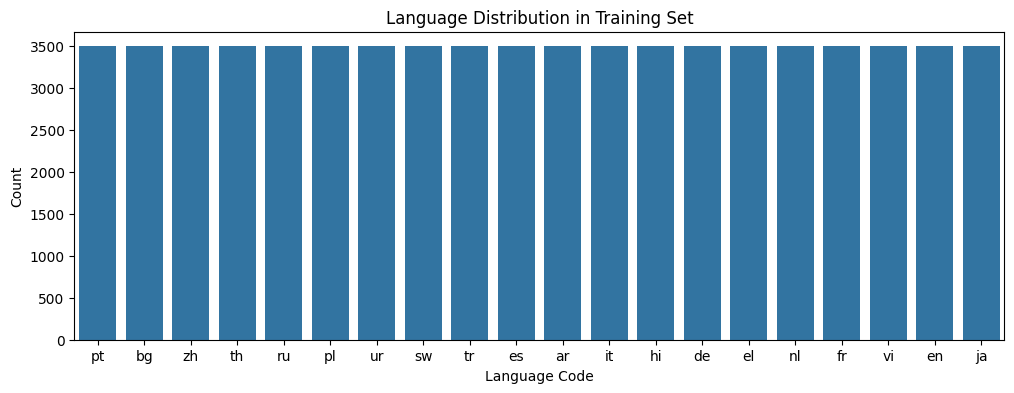

,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


In [2]:
# Load the dataset directly from Hugging Face
print("Loading papluca/language-identification dataset...")
dataset = load_dataset("papluca/language-identification")

# Convert splits to Pandas DataFrames
train_df = pd.DataFrame(dataset['train'])
val_df = pd.DataFrame(dataset['validation'])
test_df = pd.DataFrame(dataset['test'])

print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

# Display class distribution across the 20 languages
plt.figure(figsize=(12, 4))
sns.countplot(data=train_df, x='labels', order=train_df['labels'].value_counts().index)
plt.title("Language Distribution in Training Set")
plt.xlabel("Language Code")
plt.ylabel("Count")
plt.show()

train_df.head()

In [3]:
# Build a scikit-learn Pipeline with Character n-grams TF-IDF + Logistic Regression
# Enhancements: Character n-grams catch sub-word patterns for short customer queries.
lang_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='char',            # Character-level n-grams capture sub-words across languages
        ngram_range=(2, 4),         # Bi-grams, tri-grams, and 4-grams
        max_features=50000,         # Cap top features for efficiency
        sublinear_tf=True           # Logarithmic term frequency scaling (1 + log(tf))
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        C=1.0,
        solver='lbfgs',
        n_jobs=-1
    ))
])

# Train on train set
print("Training Language Detection Model...")
lang_pipeline.fit(train_df['text'], train_df['labels'])
print("Model training complete!")

Training Language Detection Model...
Model training complete!


In [4]:
# Validate on validation set
val_preds = lang_pipeline.predict(val_df['text'])
val_acc = accuracy_score(val_df['labels'], val_preds)

print(f"Validation Accuracy: {val_acc * 100:.2f}%")

Validation Accuracy: 99.43%


In [5]:
# Inference function for the full pipeline
def predict_language(text: str) -> str:
    return lang_pipeline.predict([text])[0]

# Sample test queries representing customer support interactions
sample_queries = [
    "I haven't received my refund yet.",                  # English (en)
    "Mon colis n'est pas encore arrivé, vous pouvez m'aider?", # French (fr)
    "¿Dónde está mi pedido? Lleva tres días de retraso.",  # Spanish (es)
    "Hallo, ich möchte meine Bestellung stornieren.",    # German (de)
    "Il mio ordine è arrivato danneggiato.",             # Italian (it)
]

print("--- Sample Predictions ---")
for q in sample_queries:
    lang = predict_language(q)
    print(f"[{lang.upper()}] -> \"{q}\"")

# Export model pipeline for FastAPI / Flask deployment
model_filename = "lang_detection_model.pkl"
joblib.dump(lang_pipeline, model_filename)
print(f"\nModel pipeline successfully saved as '{model_filename}'.")

# Download directly to your local computer from Colab
from google.colab import files
files.download(model_filename)

--- Sample Predictions ---
[EN] -> "I haven't received my refund yet."
[FR] -> "Mon colis n'est pas encore arrivé, vous pouvez m'aider?"
[ES] -> "¿Dónde está mi pedido? Lleva tres días de retraso."
[DE] -> "Hallo, ich möchte meine Bestellung stornieren."
[IT] -> "Il mio ordine è arrivato danneggiato."

Model pipeline successfully saved as 'lang_detection_model.pkl'.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>